In [1]:
# Make repo root importable for this session (zero packaging)
import sys, pathlib
repo_root = pathlib.Path.cwd().parent if (pathlib.Path.cwd().name == "notebooks") else pathlib.Path.cwd()
sys.path.insert(0, str(repo_root))
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import math
import time
from datetime import datetime
import os
import shutil # for copying checkpoint to "last"
from pathlib import Path
import gc

import torch
import torch.nn as nn
import torchvision.transforms as transform

from torch.utils.tensorboard import SummaryWriter
import matplotlib.pylab as plt
%matplotlib inline
from IPython.display import Audio

from rnencodec.utils.utils import param_breakdown
from rnencodec.utils.io import save_run_config

from rnencodec.audioDataLoader.audio_dataset import LatentDatasetConfig, EnCodecLatentDataset_constant, EnCodecLatentDataset_dynamic, EnCodecLatentDataset_dynamic_v2, latents_to_audio_simple, efficient_codes_to_latents
from torch.utils.data import DataLoader

import rnencodec.model.gru_audio_model
from rnencodec.model.gru_audio_model import GRUModelConfig

from transformers import EncodecModel

import torch.nn.functional as F

<div style="width: 100%; height: 5px; background-color: DarkBlue;"></div>
<b>Data sets</b>

The syn7wav24_tokens_HFdataset_5 has the following parameters:   
&nbsp;&nbsp;&nbsp;&nbsp;        ['Full File Name', 'class_name', 'param1', 'param2', 'param3', 'param0', 'audio']  
and the following unique 'class_name' values:  
&nbsp;&nbsp;&nbsp;&nbsp;        Class list: ['ChirpPattern', 'DSApplause', 'DSBugs', 'DSPeepers', 'DSPistons', 'DSWind', 'TokWotalDuet']  
which you can use to filter the full dataset if you only want to train on a subset of sound classes, for example:  
&nbsp;&nbsp;&nbsp;&nbsp;        config.filters = {'class_name': {'DSPistons', 'DSApplause'}}  
<div style="width: 100%; height: 5px; background-color: DarkBlue;"></div>

### Data Params  
<a id="dataparams"></a>

These parameters are saved to file, and serve several purposes:
* The allow other programs to properly evaluate and visualize the trained (and also saved) models,
* Provide a record of the parameters that allow reproducing results. 

In [3]:
resume_checkpoint= None #str(Path("./output/20250817_151624_pistons_2048.16_4.96/"))  # None # 

dataset="water" # "ddsp_violin"

if dataset=="syntex": # syntex
    sourcedatadir = os.path.join(os.getcwd(), '/slowdisk/esteban/scratchdata/syntex24/data7wav/syn7wav24_tokens_HFdataset_5' )  # where the data files live
    savename="multiclass_test" #"DSPistons_noTF"  #just a tag on the output folder 
    #props={"param1": (0,1)}
    props={"c1": (0, 1), "c2": (0, 1),"c3": (0, 1),"c4": (0, 1),"c5": (0, 1),"c6": (0, 1),"c7": (0, 1),"param1": (0,1)}
    filters= {}# {'class_name': {'TokWotalDuet'}} 
    train_split='train_sm'
    val_split='val'
    EnCodecLatentDataset=EnCodecLatentDataset_constant  #latents in .arrow file, column headers are param names, column values are param values - one value per audio file

elif dataset=="nsynth" : # nsynth
    sourcedatadir = os.path.join(os.getcwd(), '/slowdisk/data/MuMeRNN/data/nsynth.64.76.ecdc24HF' )  # where the data files live
    savename="deleteme"  #just a tag on the output folder 
    props={"class": (.0,1),"norm_pitch": (-.05,1.05), "norm_amp": (0,1),} #what to map into [0,1]
    filters= {} 
    train_split='train'
    val_split='train'
    EnCodecLatentDataset=EnCodecLatentDataset_constant   #latents in .arrow file, column headers are param names, column values are param values - one value per audio file

elif dataset=="water":
    sourcedatadir = os.path.join(repo_root, 'artifacts/data/waterfill_quickstart_hf_dataset' )  # where the data files live
    savename="quickstart_softcascade"  #just a tag on the output folder 
    props={"pos": None}  #what to map into [0,1]
    filters= {} 
    train_split='train'
    val_split='train'    
    EnCodecLatentDataset=EnCodecLatentDataset_dynamic   #latents in "sidecar" npy and json files and have as many frames as the audio file


elif dataset=="ddsp_violin":
    sourcedatadir = os.path.join(repo_root, '/slowdisk/data/DDSP_ViolinSet2/ddsp_violinset_hf' )  # where the data files live
    savename="ddsp_violin_seql_75_corrected"  #just a tag on the output folder 
    props={"pitch": None, "amp": None}  #what to map into [0,1]
    filters= {} 
    train_split='train'
    val_split='train'    
    EnCodecLatentDataset=EnCodecLatentDataset_dynamic_v2   #latents in "sidecar" npy and json files and have as many frames as the audio file


print(f'props are {props}')
rawqweights=torch.tensor([1.0, 0.9, 0.8, 0.7, 0.6, 0.5, 0.4, 0.3], dtype=torch.float)

params = dict(
    # Read/write directory of data & parameter files
    #*************************************
    sample_rate=24000,
    runTimeStamp='{:%Y-%m-%d_%H-%M-%S}'.format(datetime.now()),
    
    datadir = sourcedatadir,
    filters=filters,
    
    savemodel = True,
    savemodel_interval = 25, #10, # in units of epochs
    savemodeldir = os.path.join(os.getcwd(), 'output'), # default saving directory for models and the parameterization

    # Training parameters ----------------------------------------------
    num_epochs = 75, # #20, # of batches_per_epoch of batch_size sequeunce
    batches_per_epoch = 100, #100, 
    batch_size = 100, #100, 
    
    noise=.05,
    seqLen = 75, #14379, # 125, # 125,

    lr = 0.005,
    # parameter names for the Data Loader to search for in the filenames, and the range that maps to [0,1] for training and inference
    # The order specified in this structure will be the order used for inference
    props=props,
    
    # Model parameters -----------------
    input_size = 128,
    hiddenSize = 128, # 128, #100,
    nLayers = 3,
    inp_proportion = 5,
    cond_proportion = 1,
    codebook_size = 1024, # encodec codebook size
    dropout = 0.1,
    n_q = 8,                                # Number of codebooks to use
    quantizer_weights = rawqweights * (len(rawqweights) / rawqweights.sum()), #normed to sum to the length of the array
    clamp_val = 15,


    # training-time knobs you already have (not used yet)
    gumbel_tau_start = 1.0,
    gumbel_tau_end = 0.5,
    straight_through = True,

    # cascade selection
    cascade = "soft",  # "hard" | "soft"

    # HARD cascade knobs
    hard_sample_mode = "sample",
    top_n_hard = 3,   # used for both training and for the little inference thing I do at the end of each batch
    temperature_hard = 1.0,
    
    # SOFT cascade knobs (RNG-free unless you later add gumbel-soft)
    tau_soft = 0.6,
    top_n_soft = None,  # optional sparse softmax (still deterministic)

    # ----------------------------
    simulate_parallel = False,  #Simultate parallel will turn TF on and send 0's in to simulate no cascading information

    # Training parameters
    files_per_sequence=4, #important - how many different data files to draw from to create each sequence. For short seq_lens, and dynamic params, this should probably be 1
    TF_schedule = [25,25], # cycle: [TF batches, noTF batches] (make sure simulate_parallel is False if you want TF

)

# for managing the switching between TF and no TF
TF_cycle=params['TF_schedule'][0]+params['TF_schedule'][1]
use_tf = lambda epoch: (epoch % TF_cycle) < params['TF_schedule'][0]  # ['TF_schedule'][0]  on, ['TF_schedule'][1] off

props are {'pos': None}


In [4]:
params

{'sample_rate': 24000,
 'runTimeStamp': '2025-10-23_18-55-05',
 'datadir': '/home/lonce/working/RNeNcodec/artifacts/data/waterfill_quickstart_hf_dataset',
 'filters': {},
 'savemodel': True,
 'savemodel_interval': 25,
 'savemodeldir': '/home/lonce/working/RNeNcodec/notebooks/output',
 'num_epochs': 75,
 'batches_per_epoch': 100,
 'batch_size': 100,
 'noise': 0.05,
 'seqLen': 75,
 'lr': 0.005,
 'props': {'pos': None},
 'input_size': 128,
 'hiddenSize': 128,
 'nLayers': 3,
 'inp_proportion': 5,
 'cond_proportion': 1,
 'codebook_size': 1024,
 'dropout': 0.1,
 'n_q': 8,
 'quantizer_weights': tensor([1.5385, 1.3846, 1.2308, 1.0769, 0.9231, 0.7692, 0.6154, 0.4615]),
 'clamp_val': 15,
 'gumbel_tau_start': 1.0,
 'gumbel_tau_end': 0.5,
 'straight_through': True,
 'cascade': 'soft',
 'hard_sample_mode': 'sample',
 'top_n_hard': 3,
 'temperature_hard': 1.0,
 'tau_soft': 0.6,
 'top_n_soft': None,
 'simulate_parallel': False,
 'files_per_sequence': 4,
 'TF_schedule': [25, 25]}

### Run Params 

In [5]:
sr = params['sample_rate']

log_interval = 1 # units of epochs
visualize_interval = log_interval # units of epochs

#Generation parameters
#*************************************
max_length = params['seqLen']*3  #length of the sequence used to inspect progress in audio plots during training

# Cuda
#*************************************
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
#device='cpu'
device

device(type='cuda', index=0)

In [6]:
# Some utility functions
#*************************************
def time_taken(elapsed):
    """To format time taken in hh:mm:ss. Use with time.monotic()"""
    m, s = divmod(elapsed, 60)
    h, m = divmod(m, 60)
    return "%d:%02d:%02d" % (h, m, s)

def mydate() :
    return (datetime.now().strftime("%Y-%m-%d %H:%M:%S"))



In [7]:

#--- model settings ----#
model_config = GRUModelConfig (
    input_size = params['input_size'],
    cond_size = len(params['props']),
    hidden_size = params['hiddenSize'],
    num_layers = params['nLayers'],
    codebook_size = params['codebook_size'],  #mu-law quantization levels
    dropout = params['dropout'],
    n_q=params['n_q'],

    inp_proportion = params['inp_proportion'],
    cond_proportion = params['cond_proportion'],

    # training-time knobs you already have (not used yet)
    gumbel_tau_start = params['gumbel_tau_start'],
    gumbel_tau_end = params['gumbel_tau_end'],
    straight_through = params['straight_through'],

    # cascade selection
    cascade = params['cascade'],  # "hard" | "soft"

    # HARD cascade knobs
    hard_sample_mode = params['hard_sample_mode'],
    top_n_hard = params['top_n_hard'],   # used for both training and for the little inference thing I do at the end of each batch
    temperature_hard = params['temperature_hard'],

    tau_soft = params['tau_soft'],
    top_n_soft = params['top_n_soft'],  # optional sparse softmax (still deterministic)

)

    

# ---- Training Settings ----
data_config = LatentDatasetConfig(
    dataset_path=params['datadir'],
    sequence_length=params['seqLen'],
    parameter_specs=params['props'],
    add_noise= False if params['noise'] == 0 else True,   # Whether to add white noise
    noise_weight = params['noise'],                           # Desired signal-to-noise ratio (dB)
    codebook_size=params['codebook_size'],
    n_q=params['n_q'],
    clamp_val=params['clamp_val'],
    filters=filters,
    files_per_sequence=params['files_per_sequence'],

    # IMPORTANT: co-located sidecars → leave cond_root = None (default)
    cond_root=None,
    cond_suffix=".cond.npy",
    strict=False,                         # skip files with missing/mismatched sidecars instead of raising

)

# ---- Generation Settings ----
testdata_config = LatentDatasetConfig(
    dataset_path=params['datadir'],
    sequence_length=params['seqLen'],
    parameter_specs=params['props'],
    add_noise= False,                        # no noise for testing and priming
    noise_weight = params['noise'],                           # Desired signal-to-noise ratio (dB)
    codebook_size=params['codebook_size'],
    n_q=params['n_q'],
    clamp_val=params['clamp_val'],
    filters=filters,
    files_per_sequence=params['files_per_sequence'],

    # IMPORTANT: co-located sidecars → leave cond_root = None (default)
    cond_root=None,
    cond_suffix=".cond.npy",
    strict=False,                         # skip files with missing/mismatched sidecars instead of raising

)

# === Dataset and Loader ===
# Load your EnCodec model (update path as needed)
# this model we put on the GPU (or current device) and pass it to the inference engine (the datasets will have their own copy on the CPU
enc_model = EncodecModel.from_pretrained("facebook/encodec_24khz") # leave on the cpu till we are ready to train+inferece for now
enc_model.eval()

print("✅ Configuration and model loaded")


adataset = EnCodecLatentDataset(data_config, "facebook/encodec_24khz", split=train_split)

train_loader = DataLoader(adataset,
                             batch_size=params['batch_size'],
                             shuffle=True,
                             num_workers=4,
                             drop_last=True)

testdataset = EnCodecLatentDataset(testdata_config, "facebook/encodec_24khz", split=val_split)
test_loader = DataLoader(testdataset,
                            batch_size=1,
                            shuffle=True,
                            num_workers=4,
                            drop_last=True)
   
# The data "size" is the number of possible sequences the data loader can provide.
# Since the sequences are chosen randomly from the file, the number of possible sequence is the total number of audio samples in the set (minus the ones that start less than sequence length from the end of the files)
print("size of dataset is",len(adataset))
print("no. of batches per epoch is", params['batches_per_epoch'])
print("batchsize id  is", params['batch_size'])

✅ Configuration and model loaded
[EnCodecLatentDataset] No filters provided; using all 28 rows.
Loaded 29785 sequences from 28 files in 'train' split
[EnCodecLatentDataset] No filters provided; using all 28 rows.
Loaded 29785 sequences from 28 files in 'train' split
size of dataset is 29785
no. of batches per epoch is 100
batchsize id  is 100


size of dataset is 29785
no. of batches per epoch is 100
batchsize id  is 100
PVECT - shape is torch.Size([75, 1])
pvect[0]: tensor([0.1746])
pvect[last]: tensor([0.6421])
inp.shape is torch.Size([75, 128])


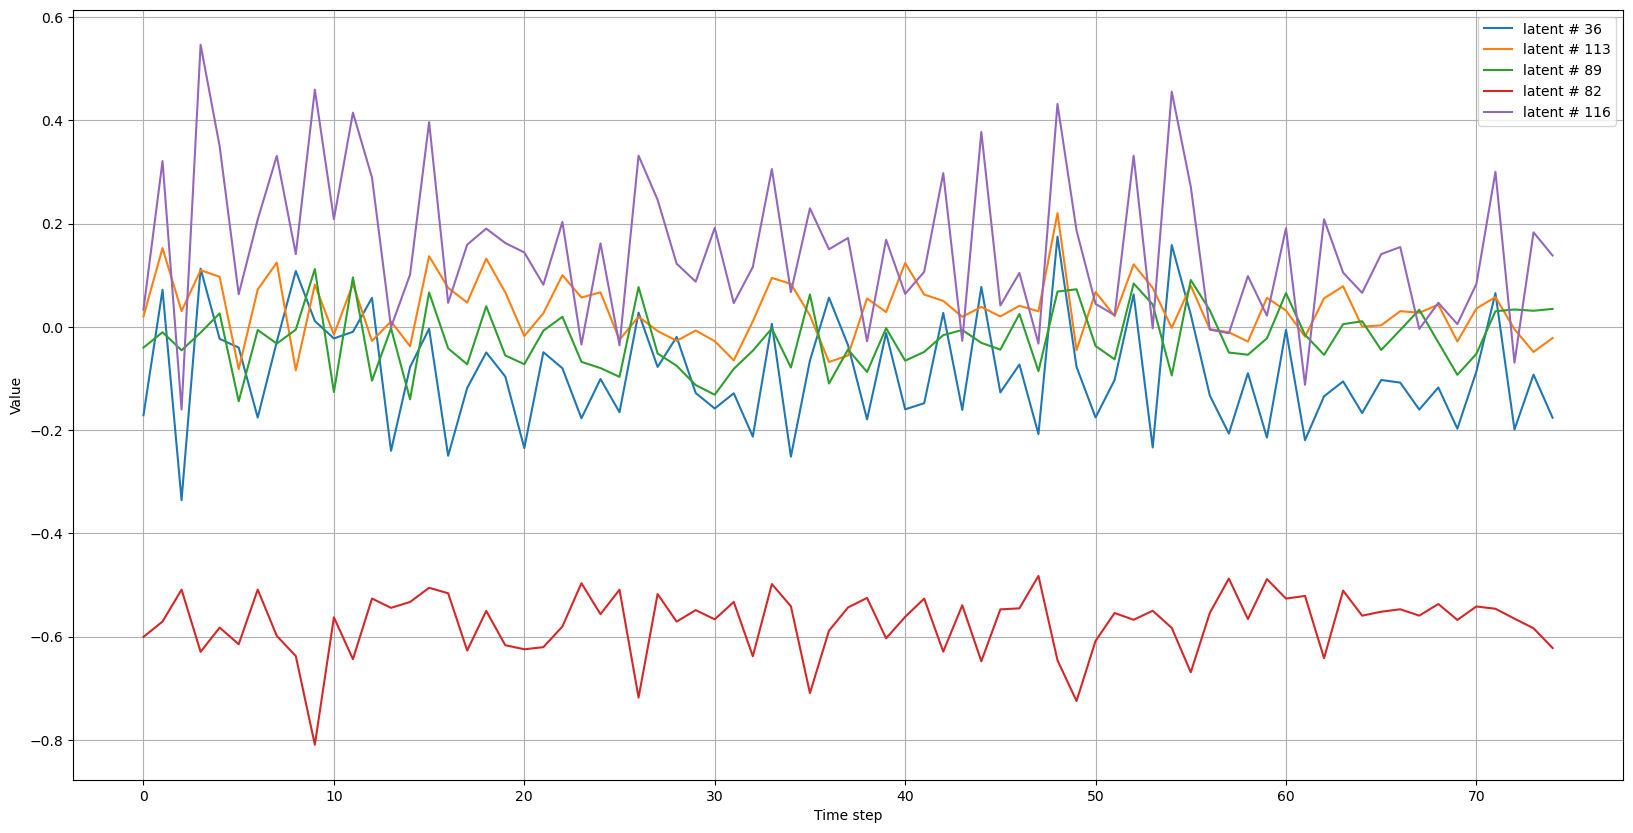

SHAPE: torch.Size([1, 128, 75])


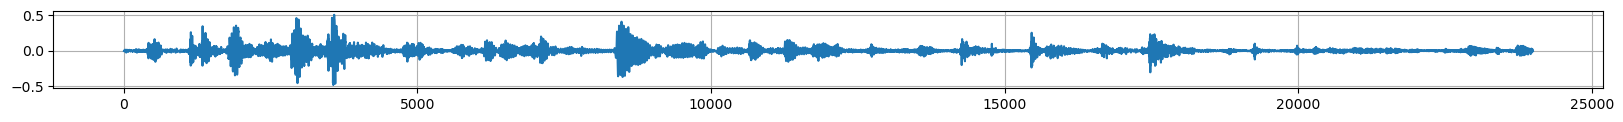

conditioning.shap = torch.Size([75, 1])


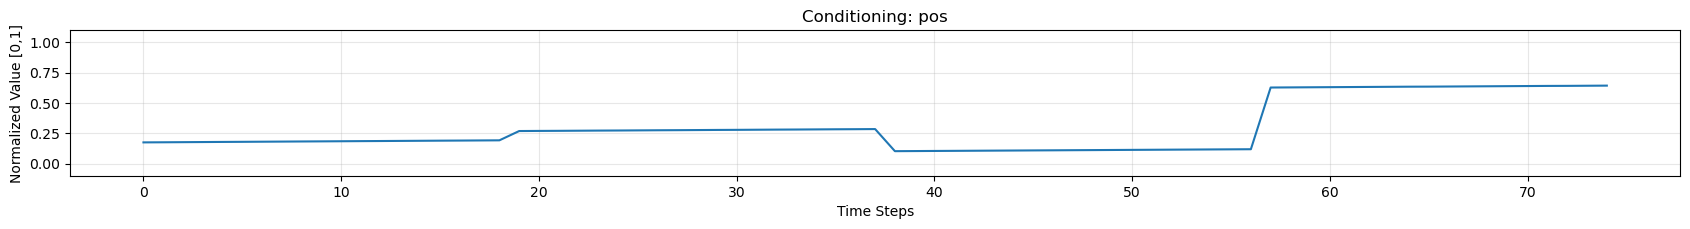

codes: ZOOM0001.ecdc cond: ZOOM0001.cond.npy start: 0


In [8]:
# just show some stuff 
def pmap(x) :
    return 55+x*(88-55)

print("size of dataset is",len(adataset))
print("no. of batches per epoch is", params['batches_per_epoch'])
print("batchsize id  is", params['batch_size'])

samp, target = adataset.rand_sample()  #samp.shape=(T, inputsize+cond_size)
pvect=samp[:, -model_config.cond_size:]
print(f'PVECT - shape is {pvect.shape}')
pvect0=samp[0, -model_config.cond_size:]
print(f"pvect[0]: {pvect0}")
pvectl=samp[params['seqLen']-1, -model_config.cond_size:]
print(f"pvect[last]: {pvectl}")

inp=samp[:,:-model_config.cond_size]
print(f'inp.shape is {inp.shape}')

# Now grab n=10 random latent components and look at them over time
_, p = inp.shape
# Generate n=10 random indices from 0 to p-1
indices = torch.randperm(p)[:5]
sub_inp = inp[:, indices]
sub_inp.shape


#first print latent sequence
plt.figure(figsize=(20,10)) 
# plt.plot(np.arange(len(sub_inp)), sub_inp) #just print some example from the batch
# plt.grid()
# plt.show()

ts = np.arange(len(sub_inp))  # time steps
for i in range(sub_inp.shape[1]):   # loop over trajectories
    plt.plot(ts, sub_inp[:, i], label=f"latent # {indices[i]}")
plt.legend()
plt.xlabel("Time step")
plt.ylabel("Value")
plt.grid()
plt.show()



tokens=samp[:, :params['input_size']].T.unsqueeze(0)
print(f"SHAPE: {tokens[:,:params['input_size']].shape}")
audiosamps, sr=latents_to_audio_simple(enc_model, tokens*params['clamp_val'])
audiosamps=audiosamps[0, 0]

plt.figure(figsize=(20,1)) 
plt.plot(audiosamps) #just print one example from the batch
plt.grid()
plt.show()


#conditioning = samp[:,-model_config.cond_size:]
cvect = pvect#=samp[:, -model_config.cond_size:] # samp[:, -model_config.cond_size:].squeeze(0)  #imp_seq[0, :, -len(params['props']):]
n_params = cvect.shape[1]
print(f'conditioning.shap = {cvect.shape}')
# # Additional Analysis: Conditioning parameters over time
if n_params > 0:
    plt.figure(figsize=(17, 4))
    
    param_names = list(data_config.parameter_specs.keys())
    
    for i in range(n_params):
        plt.subplot(2, (n_params + 1) // 2, i + 1)
        plt.plot(cvect[:,i].numpy())
        param_name = param_names[i] if i < len(param_names) else f'param_{i}'
        plt.title(f'Conditioning: {param_name}')
        plt.xlabel('Time Steps')
        plt.ylabel('Normalized Value [0,1]')
        plt.grid(True, alpha=0.3)
        plt.ylim(-0.1, 1.1)
    
    plt.tight_layout()
    plt.show()

    # #print out numbers
    # cvect_mapped = torch.stack([pmap(cvect[:, 0]), cvect[:, 1]], dim=1)
    # print(f"conditioning params: {cvect_mapped}")

#Another check just to see that the ecdc and params are coming from the same file and using the same starting sample number (no using the random sample as above)
entry = adataset.sequence_map[0]         # (dataset_idx, start_frame, token_file_path)
ds_idx, start, token_path = entry
cpath = adataset._cond_path_for(token_path)
print("codes:", token_path.name, "cond:", cpath.name, "start:", start)


#This is the "rand_samp" plotted above"
Audio(audiosamps, rate=params['sample_rate'])

In [9]:

def prepare_target_codebook_latents(rnn_model, target_codes, scales_bq=None):
    """
    target_codes: (B, n_q) LongTensor for a single timestep
    returns: List[n_q] of (B, D=128) latents, one per codebook (level 0..n_q-1)
    """
    dev = rnn_model._E_eff.device
    codes_bq = target_codes.to(dev, dtype=torch.long, non_blocking=True)
    if scales_bq is not None:
        scales_bq = scales_bq.to(dev, non_blocking=True)

    out = []
    for q in range(rnn_model.n_q):
        E_q = rnn_model._E_eff[q]                    # (K, D)
        e_q = F.embedding(codes_bq[:, q], E_q)       # (B, D)
        if scales_bq is not None:
            e_q = e_q * scales_bq[:, q].unsqueeze(-1)
        out.append(e_q)
    return out

In [10]:
# Define the training cycle (100% teacher forcing for now)
#*************************************

def train(model,encodec_model, epoch):

 model.train() #put in training mode
 ave_loss_over_steps = 0
 debug_seqs=0

 for batch_num, (inp, target) in enumerate(train_loader):
    debug_seqs += len(inp)
    inp, target = inp.to(device), target.to(device)
    
    hidden = model.init_hidden(params['batch_size'])
    optimizer.zero_grad()
    loss = 0
    
    # Initialize per-quantizer loss tracking
    quantizer_losses = [0.0] * params['n_q']
    
    # Define quantizer weights
    quantizer_weights = params['quantizer_weights'][:params['n_q']]
     
    for i in range(params['seqLen']):  # causal: one time step at a time
        if params['simulate_parallel']:
            use_teacher_forcing = True
            # just placeholders for shape when sim-parallel; zeros are fine
            tflatents = [torch.zeros(params['batch_size'], params['input_size'], device=device)
                         for _ in range(params['n_q'])]
        else:
            use_teacher_forcing = use_tf(epoch)
            if use_teacher_forcing:
                # prepare ground-truth per-level latents (List[n_q * (B,128)])
                tflatents = prepare_target_codebook_latents(model, target[:, i, :]) # uses model's decoder
            else:
                tflatents = None
    
        # --- ONE call; ONE set of sampled tokens used everywhere ---
        logits_list, hidden, sampled_indices, step_latent = model(
            inp[:, i, :],
            hidden,
            target_codebook_latents=tflatents,
            use_teacher_forcing=use_teacher_forcing,
            return_step_latent=False, # this is for "self conditioning"

        )
    
        # --- CE loss exactly as before (per-quantizer) ---
        for j in range(params['n_q']):
            quantizer_loss = criterion(logits_list[j], target[:, i, j])
            quantizer_losses[j] += quantizer_loss.item()
            loss = loss + quantizer_weights[j] * quantizer_loss
    
        # # --- Self-conditioning for next step: feed SAME latent forward ---
        # if i + 1 < params['seqLen']:
        #     # step_latent is:
        #     #  - the sum of teacher-forced per-level latents if TF,
        #     #  - the sum of decoded sampled tokens if AR.
        #     # Use .detach() for stable training (no across-time grads for now).
        #     inp[:, i + 1, :params['input_size']] = step_latent.detach()
    
    loss = loss / params['seqLen']
    quantizer_losses = [ql / params['seqLen'] for ql in quantizer_losses]
    
    loss.backward()
    optimizer.step()
    
    ave_loss_per_sample = loss.item()/params['seqLen']   #over each minibatch
    #ave_loss_over_steps += ave_loss_per_sample
    
    # Accumulate quantizer losses over the epoch
    if batch_num == 0:  # Initialize on first batch
        epoch_quantizer_losses = [0.0] * params['n_q']
    
    for j in range(params['n_q']):
        epoch_quantizer_losses[j] += quantizer_losses[j]
    
    if batch_num>=(params['batches_per_epoch']-1):
        break


    per_q_time_mean = [s / params['seqLen'] for s in quantizer_losses]  # each is batch-mean, time-mean
    overall_time_mean = float(torch.dot(quantizer_weights, torch.tensor(per_q_time_mean, device=quantizer_weights.device)).item())

    
 print(f"Finished epoch number {epoch} with a total of {debug_seqs} debug_seqs")
 if (epoch+1) % log_interval == 0:
    print(f" time: {datetime.now()}, epoch {epoch+1},  Loss: {ave_loss_per_sample:.4f}")
    list_of_losses.append(ave_loss_per_sample)
    writer.add_scalar("Loss/train", ave_loss_per_sample, epoch+1)
    writer.add_scalar("overall_time_mean", overall_time_mean, epoch+1)
    
    # Log individual quantizer losses (averaged over the epoch)
    num_batches = min(batch_num + 1, params['batches_per_epoch'])
    for j in range(params['n_q']):
        avg_quantizer_loss = epoch_quantizer_losses[j] / num_batches
        writer.add_scalar(f"Loss/quantizer_{j}", avg_quantizer_loss, epoch+1)
        print(f"  Quantizer {j} Loss: {avg_quantizer_loss:.4f}")

 if (epoch+1) % visualize_interval == 0:

     # these two lines address a resource management issues with temporary directories ...  I think....
     torch.cuda.empty_cache()  # if using GPU
     gc.collect()

     result = newgen(model,max_length)
     print(f'plot the audio which has shape {result.shape}')
     plt.figure(figsize=(20,1))
     plt.plot(np.arange(len(result)), result) #just print one example from the batch
     plt.show()
     model.train() #put model back to training mode


 # overwrite the last, and save a numbered checkpoint
 if (epoch + 1) % params['savemodel_interval'] == 0:
    checkpoint_data = {
        'epoch': epoch+1,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict()
    }
    
    # Save numbered checkpoint
    numbered_path = os.path.join(f"{out_dir}/checkpoints", f"checkpoint_{epoch+1}.pt")
    torch.save(checkpoint_data, numbered_path)
    
    # Copy to "last" (much faster than saving twice)
    last_path = os.path.join(f"{out_dir}/checkpoints", "last_checkpoint.pt")
    shutil.copy2(numbered_path, last_path)
    
    print(f"Saved checkpoint at epoch {epoch+1}")

In [11]:
# ---- Create Output Folders ----
if resume_checkpoint != None:
    out_dir = resume_checkpoint
else:
    run_timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    out_dir = os.path.join(params['savemodeldir'], run_timestamp + "_"+savename)
    os.makedirs(out_dir, exist_ok=True)

    os.makedirs(out_dir, exist_ok=True)
    os.makedirs(f"{out_dir}/checkpoints", exist_ok=True)
    os.makedirs(f"{out_dir}/tensorboard", exist_ok=True)


# # ---- Save Config ----
# #machine readable
# torch.save({
#     "model_config": model_config,
#     "data_config": data_config
# }, f"{out_dir}/config_v1.pt")


# #human readable
# with open(f"{out_dir}/config_v1.txt", "w") as f: 
#     f.write("params = " + repr(params) + "\\n")
#     f.write("model_config = " + repr(model_config) + "\\n")
#     f.write("data_config = " + repr(data_config) + "\\n")

#This can replace the above 2 torch.save calls 
save_run_config(f"{out_dir}/config_v2.pt", params=None, model_config=model_config, data_config=data_config)
print(f"wrote {out_dir}/config_v2.pt")

saved to /home/lonce/working/RNeNcodec/notebooks/output/20251023_185506_quickstart_softcascade/config_v2.pt
wrote json param file
wrote /home/lonce/working/RNeNcodec/notebooks/output/20251023_185506_quickstart_softcascade/config_v2.pt


In [12]:
from rnencodec.generator import RNNGenerator



def newgen(model,max_length):
    rnninference=RNNGenerator(model, model_config, testdata_config, enc_model, max_length, max_length)
    
    # grab a random conditioning vector from the data set
    p_inp, _ = next(iter(test_loader)) # don't need targets
    c = p_inp[:, 0, -model_config.cond_size:].squeeze(0).to(device) #grab a random input sequence
    print(f'DEVICE going in: model tensors {next(model.parameters()).device}, enc_model {enc_model.device}, c {c.device}')
    print(f'About toInitialize generator with c.shape = {c.shape}') 
    rnninference.warmup(c,10)
    gen = rnninference.getNextAudioHop(c, hop=max_length)
    
    return gen

In [13]:
model_config

GRUModelConfig(input_size=128, cond_size=1, hidden_size=128, num_layers=3, n_q=8, codebook_size=1024, dropout=0.1, inp_proportion=5, cond_proportion=1, gumbel_tau_start=1.0, gumbel_tau_end=0.5, straight_through=True, cascade='soft', hard_sample_mode='sample', top_n_hard=3, temperature_hard=1.0, tau_soft=0.6, top_n_soft=None)

### Load the model 

In [14]:

rnn = rnencodec.model.gru_audio_model.RNN(model_config, enc_model).to(device)
    
optimizer = torch.optim.Adam(rnn.parameters(), lr=params['lr'])
criterion = nn.CrossEntropyLoss(reduction='mean')

start_epoch=0

if resume_checkpoint:
    checkpoint_path = os.path.join(f"{out_dir}/checkpoints", "last_checkpoint.pt")
    assert os.path.exists(checkpoint_path), f"File {checkpoint_path} does not exist"
    checkpoint = torch.load(checkpoint_path)
    rnn.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    start_epoch = checkpoint['epoch'] + 1
    print(f"Resumed from checkpoint at epoch {start_epoch}")

writer = SummaryWriter(log_dir=f"{out_dir}/tensorboard")

Latents embedded in 106 of the GRU input size of 128
Conditioning parameters embedded in 22 of the GRU input size of 128


In [15]:
num_trainable_params = sum(p.numel() for p in rnn.parameters() if p.requires_grad)
print(f"Total trainable parameters: {num_trainable_params}")

bd = param_breakdown(rnn, trainable_only=True) #prints out a breakdown of the parameter counts per layter
# pretty print
print(f"latent_proj: {bd['latent_proj']:,}")
print(f"cond_proj:   {bd['cond_proj']:,}")
print(f"GRU total:   {bd['gru_total']:,}")
for k, v in bd['gru_layers'].items():
    print(f"  {k}: {v:,}")
print("Decoders (per head):")
for i, n in enumerate(bd['decoders']):
    print(f"  decoder[{i}]: {n:,}")
print(f"Decoders total: {bd['decoders_total']:,}")
print(f"Model total:    {bd['model_total']:,}")


n_q, K, D = rnn._E_eff.shape
print(f"✅ E_eff is built: n_q={n_q}, K={K}, D={D}, device={rnn._E_eff.device}")
# per-level shapes (each should be (K, D))
print("Per-level shapes:", [tuple(rnn._E_eff[q].shape) for q in range(n_q)])


# 1) Make sure both models are on the same device
device = next(rnn.parameters()).device
enc_model = enc_model.to(device)

B, T = 4, 7
codes = torch.randint(0, rnn.codebook_size, (B, T, rnn.n_q), device=device, dtype=torch.long)

# 3) Manual path via cached effective tables (matches Encodec exactly)
z_manual = rnn._codes_to_latent_sum(codes)                           # (B, T, D)

# 4) Encodec path (expects (n_q, B, T))
z_decode = enc_model.quantizer.decode(codes.permute(2, 0, 1))        # (B, D, T)
z_decode = z_decode.permute(0, 2, 1).contiguous()                    # (B, T, D)

# 5) Compare
diff = (z_manual - z_decode).abs()
print("DIFFERENCE — max|Δ|=", diff.max().item(), "mean|Δ|=", diff.mean().item())

Total trainable parameters: 2416278
latent_proj: 13,674
cond_proj:   44
GRU total:   297,216
  l0/fwd: 99,072
  l1/fwd: 99,072
  l2/fwd: 99,072
Decoders (per head):
  decoder[0]: 263,168
  decoder[1]: 263,168
  decoder[2]: 263,168
  decoder[3]: 263,168
  decoder[4]: 263,168
  decoder[5]: 263,168
  decoder[6]: 263,168
  decoder[7]: 263,168
Decoders total: 2,105,344
Model total:    2,416,278
✅ E_eff is built: n_q=8, K=1024, D=128, device=cuda:0
Per-level shapes: [(1024, 128), (1024, 128), (1024, 128), (1024, 128), (1024, 128), (1024, 128), (1024, 128), (1024, 128)]
DIFFERENCE — max|Δ|= 0.0 mean|Δ|= 0.0


In [16]:
# Train!
#*************************************
enc_model.to(device)
list_of_losses = []

print('{:%Y-%m-%d %H:%M:%S} Starting training...'.format(datetime.now()))
start_time = time.monotonic()
#-------------------------------------------------------------------------------
for epoch in range(start_epoch, start_epoch+params['num_epochs']):
    train(rnn,enc_model,epoch)
#-------------------------------------------------------------------------------
writer.close()
elapsed_time = time.monotonic() - start_time
print('Training time taken:',time_taken(elapsed_time))

#Just make sure the final model gets saved
checkpoint_data = {
    'epoch': epoch+1,
    'model_state_dict': rnn.state_dict(),
    'optimizer_state_dict': optimizer.state_dict()
}
# Save numbered checkpoint
numbered_path = os.path.join(f"{out_dir}/checkpoints", f"checkpoint_{epoch+1}.pt")
torch.save(checkpoint_data, numbered_path)
print(f"Saved checkpoint at epoch {epoch+1}")
# Copy to "last" (much faster than saving twice)
last_path = os.path.join(f"{out_dir}/checkpoints", "last_checkpoint.pt")
shutil.copy2(numbered_path, last_path)


2025-10-23 18:55:07 Starting training...
Finished epoch number 0 with a total of 10000 debug_seqs
 time: 2025-10-23 18:55:19.830826, epoch 1,  Loss: 0.5085
  Quantizer 0 Loss: 4.6559
  Quantizer 1 Loss: 4.9197
  Quantizer 2 Loss: 5.1430
  Quantizer 3 Loss: 5.2516
  Quantizer 4 Loss: 5.4279
  Quantizer 5 Loss: 5.5851
  Quantizer 6 Loss: 5.7173
  Quantizer 7 Loss: 5.7915
DEVICE going in: model tensors cuda:0, enc_model cuda:0, c cuda:0
About toInitialize generator with c.shape = torch.Size([1])
params_seq.shape = torch.Size([10, 1])


TypeError: 'NoneType' object is not subscriptable

In [ ]:
# Plot the loss over time
#*************************************
plt.figure()
plt.plot(list_of_losses)
plt.show()  # This will actually display the plot

In [ ]:
list_of_losses